In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
import pandas as pd

from quant_ml.config import INTERIM_DATA_DIR
from quant_ml.baseline import (
    compute_momentum_signal,
    equal_weight_portfolio,
    compute_strategy_returns,
)

df = pd.read_parquet(INTERIM_DATA_DIR / "model_dataset_v1.parquet")
df.head()

,date,ticker,open,high,low,close,volume,fed_funds,cpi,unemployment,...,ma_ratio_20,ma_ratio_50,ma_ratio_100,ma_cross_20_50,vol_20d,vol_60d,volume_z_20,volume_ratio_20,fwd_ret_5d,target_up_5d
0,2012-05-24,EEM,27.678185,27.685539,27.192732,27.457525,57707700,0.16,228.713,8.2,...,-0.064118,-0.101638,-0.110964,-0.040091,0.010547,0.012934,-0.023332,0.993897,-0.017145,0.0
1,2012-05-25,EEM,27.347199,27.486950,27.251579,27.325134,47685000,0.16,228.713,8.2,...,-0.062567,-0.102952,-0.114840,-0.043080,0.010403,0.012836,-0.726949,0.815904,-0.008076,0.0
2,2012-05-29,EEM,28.060670,28.215132,27.854718,28.097446,71172100,0.16,228.713,8.2,...,-0.031157,-0.074966,-0.089674,-0.045218,0.012968,0.013456,0.776170,1.185941,-0.032723,0.0
3,2012-05-30,EEM,27.560501,27.692897,27.435458,27.611988,80092500,0.16,228.713,8.2,...,-0.041870,-0.088131,-0.105153,-0.048282,0.012950,0.013457,1.279838,1.289009,0.013053,1.0
4,2012-05-31,EEM,27.663479,27.869428,27.376621,27.729677,66528900,0.16,228.713,8.2,...,-0.031956,-0.081809,-0.101227,-0.051499,0.013127,0.012851,0.225904,1.044534,0.014854,1.0


In [3]:
df = compute_momentum_signal(df)
df = equal_weight_portfolio(df)

portfolio = compute_strategy_returns(df)

portfolio.head()

,gross_return,cost,net_return,cum_return
date,,,,
2012-05-24,0.000000,0.000,0.000000,1.000000
2012-05-25,0.000000,0.001,-0.001000,0.999000
2012-05-29,0.004516,0.000,0.004516,1.003512
2012-05-30,0.005426,0.000,0.005426,1.008957
2012-05-31,0.004687,0.000,0.004687,1.013685


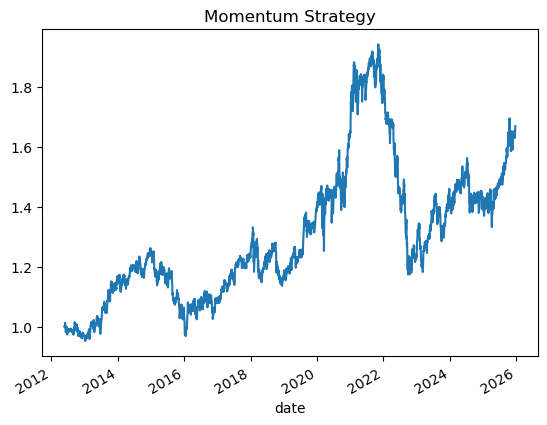

In [4]:
import matplotlib.pyplot as plt

portfolio["cum_return"].plot(title="Momentum Strategy")
plt.show()

In [5]:
import numpy as np

returns = portfolio["net_return"].dropna()

sharpe = np.sqrt(252) * returns.mean() / returns.std()
max_dd = (portfolio["cum_return"] / portfolio["cum_return"].cummax() - 1).min()

print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

Sharpe: 0.3402645096383136
Max Drawdown: -0.3951590910473667


In [6]:
portfolio = compute_strategy_returns(df)

In [7]:
returns = portfolio["net_return"].dropna()

sharpe = np.sqrt(252) * returns.mean() / returns.std()
max_dd = (portfolio["cum_return"] / portfolio["cum_return"].cummax() - 1).min()

print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

Sharpe: 0.3402645096383136
Max Drawdown: -0.3951590910473667
